In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, models ,regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, BatchNormalization, Dense, Activation, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, ELU
from tensorflow.keras.activations import gelu
from sklearn.decomposition import PCA


from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

import keras
from sklearn.metrics import brier_score_loss, roc_auc_score, accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

from math import isfinite

from collections import defaultdict
from tensorflow.keras.callbacks import Callback

from itertools import combinations


In [1]:
from get_train_test import TrainTestBuilder
from catboost import CatBoostClassifier
from sklearn.metrics import brier_score_loss

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from catboost.utils import get_gpu_device_count
print(get_gpu_device_count())
from sklearn.metrics import accuracy_score

1


In [56]:
df_history = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\train_results_dualnn.csv')
df_results = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\test_results_dualnn.csv')
df_model = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\entire_odds_stats_2025-11-19.csv')

In [8]:
cols_to_convert = ['math_red', 'math_blue']
df_model[cols_to_convert] = df_model[cols_to_convert].astype(str)

In [3]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\entire_odds_stats_2025-12-04.csv'
df_model = pd.read_csv(fp)

non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red','winner_name',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'red_fighter_odds','blue_fighter_odds',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'performance_bonus_winner', 'fight_otn_bonus'
] #'close1_blue','close1_red','close2_blue','close2_red',

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.8, random_state=42)

builder.filter_by_year(2011, date_col='event_date')
builder.categorize_line_movement()


#        'proba_fair_open_red', 'proba_fair_open_blue',
    #    'proba_fair_close1_red', 'proba_fair_close1_blue',
    #    'proba_fair_close2_red', 'proba_fair_close2_blue', 
    #    'pimp_close1_red', 'pimp_close1_blue', 'pimp_close2_red', 'pimp_close2_blue','pimp_open_red', 'pimp_open_blue',

selected_feats = [
        'open_blue','open_red', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',

       'juice_close1_blue', 'juice_close1_red', 'juice_close2_blue','juice_close2_red','juice_open_blue','juice_open_red',
        
       'months_since_diff', 
       'win_pct_red',
       'win_pct_blue', 'num_fights_diff',
        'wins_diff', 'losses_diff',
        'ko_wins_red', 'sub_wins_red','ko_wins_blue', 'sub_wins_blue','decision_wins_diff',
       
        'fav_counts_red','fav_counts_blue', 'dog_counts_blue', 'dog_counts_red',
        'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red' ,

        'proba_fair_open_blue', 'proba_fair_open_red',
        'age_diff', 'reach_diff', 'event_age', 
        'sig_str_absorbed_total_diff', 'sig_str_absorbed_pm_diff', 'head_str_total_diff',
        'kd_total_diff', 'td_attempted_pm_diff','td_attempted_total_diff','ratio_td_blue','ratio_td_red',
        'max_elo_win_blue', 'max_elo_win_red','max_glicko_win_red', 'max_glicko_win_blue', 
        'td_defense_pct_blue', 'td_defense_pct_red', 'ratio_control_blue','ratio_control_red',
        'win_streak_diff','lose_streak_diff', 'weight_class', 'math_red', 'math_blue', 'total_bonus_diff']
        
X_train, X_test, y_train, y_test, df_train, df_test = builder.prepare_train_test(selected_feats)

X_train['proba_open_blue'] = df_history['blue_probs'].values
X_train['proba_open_red'] = df_history['red_probs'].values

X_test['proba_open_blue'] = df_results['blue_probs'].values
X_test['proba_open_red'] = df_results['red_probs'].values

X_train['pred_winner'] = (X_train['proba_open_red'] > X_train['proba_open_blue']).astype(int)
X_test['pred_winner'] = (X_test['proba_open_red'] > X_test['proba_open_blue']).astype(int)


# cat_feats = ['red_movement_close1_cat' ,'red_movement_close2_cat', 'blue_movement_close1_cat', 'blue_movement_close2_cat', 
#             'pred_winner']      
# cat_feats = ['pred_winner']
# cat_feats = ['weight_class', 'math_red', 'math_blue']

all_feats = selected_feats #+ cat_feats #+ ['proba_open_blue', 'proba_open_red']
X_train = X_train[all_feats].copy()
X_test = X_test[all_feats].copy()


# Check column shapes
print(len(X_train.columns), len(X_test.columns))
print(X_train.shape)

# X_train[cat_feats] = X_train[cat_feats].astype(int)
# X_test[cat_feats]  = X_test[cat_feats].astype(int)

Filtered: kept 6331 rows from year 2011 onward.
CAT SHAPE (6331, 278)
PREPARE SHAPE: (4654, 278)
MODEL SHAPE: (4569, 278)
Categorical columns: ['weight_class']
Numerical columns: ['open_blue', 'open_red', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue', 'juice_close1_blue', 'juice_close1_red', 'juice_close2_blue', 'juice_close2_red', 'juice_open_blue', 'juice_open_red', 'months_since_diff', 'win_pct_red', 'win_pct_blue', 'num_fights_diff', 'wins_diff', 'losses_diff', 'ko_wins_red', 'sub_wins_red', 'ko_wins_blue', 'sub_wins_blue', 'decision_wins_diff', 'fav_counts_red', 'fav_counts_blue', 'dog_counts_blue', 'dog_counts_red', 'line_movement_close1_blue', 'line_movement_close1_red', 'line_movement_close2_blue', 'line_movement_close2_red', 'proba_fair_open_blue', 'proba_fair_open_red', 'age_diff', 'reach_diff', 'event_age', 'sig_str_absorbed_total_diff', 'sig_str_absorbed_pm_diff', 'head_str_total_diff', 'kd_total_diff', 'td_attempted_pm_diff', 'td_attempted_total_diff', 'ratio_td

NameError: name 'df_history' is not defined

In [58]:
def split_red_blue_features(df: pd.DataFrame):

    red_cols = [c for c in df.columns if "red" in c]
    blue_cols = [c for c in df.columns if "blue" in c]
    diff_cols = [c for c in df.columns if "diff" in c]

    # Construct red dataframe
    red_df = df[red_cols + diff_cols].copy()
    if 'event_age' in df.columns:
        red_df['event_age'] = df['event_age']

    # Construct blue dataframe
    blue_df = df[blue_cols].copy()
    for c in diff_cols:
        blue_df[c] = -df[c]  # negate diffs for blue
    if 'event_age' in df.columns:
        blue_df['event_age'] = df['event_age']
    # Update blue_cols to include diffs as well
    blue_cols = blue_cols + diff_cols

    return red_df, blue_df, red_cols + diff_cols, blue_cols

def split_fav_dog(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Splits dataset into favorite (fav) and underdog (dog) based on open odds.
    Standardizes column names to fav_* and dog_*.
    Adjusts 'diff' columns so that they are always (fav - dog).
    
    Args:
        df (pd.DataFrame): Input dataframe with 'open_red' and 'open_blue'.
    
    Returns:
        fav_df (pd.DataFrame): Rows corresponding to the favorite (fav_* + diff_*).
        dog_df (pd.DataFrame): Rows corresponding to the underdog (dog_* + diff_*).
    """
    fav_rows = []
    dog_rows = []

    df = df.copy()
    # df = df.drop(columns=['fav_counts_red', 'dog_counts_red', 'fav_counts_blue', 'dog_counts_blue'])

    for _, row in df.iterrows():
        # --- case: red is favorite ---
        if row["open_red"] < row["open_blue"]:
            fav_row = {col.replace("red", "fav"): row[col] for col in row.index if "red" in col}
            dog_row = {col.replace("blue", "dog"): row[col] for col in row.index if "blue" in col}
            diff_row = {col.replace("diff", "diff"): row[col] for col in row.index if "diff" in col}

        # --- case: blue is favorite ---
        elif row["open_blue"] < row["open_red"]:
            fav_row = {col.replace("blue", "fav"): row[col] for col in row.index if "blue" in col}
            dog_row = {col.replace("red", "dog"): row[col] for col in row.index if "red" in col}
            diff_row = {col.replace("diff", "diff"): row[col] for col in row.index if "diff" in col}
        # --- case: tie → red as favorite ---
        else:
            fav_row = {col.replace("red", "fav"): row[col] for col in row.index if "red" in col}
            dog_row = {col.replace("blue", "dog"): row[col] for col in row.index if "blue" in col}
            diff_row = {col.replace("diff", "diff"): row[col] for col in row.index if "diff" in col}
        
        fav_row['event_age'] = row['event_age']
        dog_row['event_age'] = row['event_age']

        if row["open_red"] < row["open_blue"]:
            fav_row.update(diff_row)
            dog_row.update({key:-value for key, value in diff_row.items()})
        elif row["open_blue"] < row["open_red"]:
            fav_row.update({key:-value for key, value in diff_row.items()})
            dog_row.update(diff_row)
        else:
            fav_row.update(diff_row)
            dog_row.update({key:-value for key, value in diff_row.items()})

        fav_rows.append(fav_row)
        dog_rows.append(dog_row)
    
    fav_df = pd.DataFrame(fav_rows)
    dog_df = pd.DataFrame(dog_rows)

    y_fav_dog = []
    for _, row in df.iterrows():
        # Determine who is favorite
        if row['open_red'] <= row['open_blue']:  # red is fav or tie → red fav
            fav_won = 1 if row['winner'] == 1 else 0
        else:  # blue is fav
            fav_won = 1 if row['winner'] == 0 else 0
        
        y_fav_dog.append(fav_won)
    print(df['event_age'].isna().sum())
    return fav_df, dog_df, np.array(y_fav_dog)

In [59]:
red_train, blue_train, red_cols, blue_cols = split_red_blue_features(X_train)
red_test, blue_test, _, _ = split_red_blue_features(X_test)

fav_train, dog_train, y_favdog_train = split_fav_dog(pd.concat([X_train, y_train],axis=1, ignore_index=False))
fav_test, dog_test, y_favdog_test = split_fav_dog(pd.concat([X_test, y_test],axis=1, ignore_index=False))

X_train = pd.concat([fav_train, dog_train], axis=1)
X_test = pd.concat([fav_test, dog_test], axis=1)


0
0


In [60]:
X_train.columns

Index(['open_fav', 'close1_fav', 'close2_fav', 'juice_close1_fav',
       'juice_close2_fav', 'juice_open_fav', 'win_pct_fav', 'ko_wins_fav',
       'sub_wins_fav', 'fav_counts_fav', 'dog_counts_fav',
       'line_movement_close1_fav', 'line_movement_close2_fav',
       'proba_fair_open_fav', 'ratio_td_fav', 'max_elo_win_fav',
       'max_glicko_win_fav', 'td_defense_pct_fav', 'ratio_control_fav',
       'math_fav', 'event_age', 'months_since_diff', 'num_fights_diff',
       'wins_diff', 'losses_diff', 'decision_wins_diff', 'age_diff',
       'reach_diff', 'sig_str_absorbed_total_diff', 'sig_str_absorbed_pm_diff',
       'head_str_total_diff', 'kd_total_diff', 'td_attempted_pm_diff',
       'td_attempted_total_diff', 'win_streak_diff', 'lose_streak_diff',
       'total_bonus_diff', 'open_dog', 'close1_dog', 'close2_dog',
       'juice_close1_dog', 'juice_close2_dog', 'juice_open_dog', 'win_pct_dog',
       'ko_wins_dog', 'sub_wins_dog', 'fav_counts_dog', 'dog_counts_dog',
       'line_

In [72]:

def calc_net_odds(df_test_results, odds_type):    

    df_test_results['proba_choice'] = np.where(df_test_results['pred_winner']==1, df_test_results['red_probs'], df_test_results['blue_probs'])
    df_test_results['dec_choice'] = np.where(df_test_results['pred_winner']==1, df_test_results[f'dec_{odds_type}_red'], df_test_results[f'dec_{odds_type}_blue'])
    df_test_results['ev'] = df_test_results['proba_choice'] * (df_test_results['dec_choice']-1) - (1-df_test_results['proba_choice']) * 1

    df_ev = df_test_results[df_test_results['ev']>0].copy()
    df_ev['fav_red'] = np.where((df_ev[f'{odds_type}_red'] <= df_ev[f'{odds_type}_blue']), 1, 0)
    df_ev['fav_blue'] = np.where(df_ev[f'{odds_type}_blue'] < df_ev[f'{odds_type}_red'], 1, 0)


    fav_sum = []
    dog_sum = []

    for _, row in df_ev.iterrows():
        # correct pred  
        if row['pred_winner'] == row['winner']:

            # red 
            if row['pred_winner'] == 1:
                #red fav
                if row[f'{odds_type}_red'] <= row[f'{odds_type}_blue']:
                    fav_sum.append(row[f'dec_{odds_type}_red']-1) # fav 
                # red dog 
                else: 
                    dog_sum.append(row[f'dec_{odds_type}_red']-1) # dog
        
            # blue 
            else: 
                # blue fav 
                if row[f'{odds_type}_blue'] <= row[f'{odds_type}_red']:
                    fav_sum.append(row[f'dec_{odds_type}_blue']-1) # fav 
                # blue dog 
                else: 
                    dog_sum.append(row[f'dec_{odds_type}_blue']-1) # dog 

        # incorrect pred 
        else: 
            
            # red 
            if row['pred_winner'] == 1:
                #fav 
                if row[f'{odds_type}_red'] <= row[f'{odds_type}_blue']:
                    fav_sum.append(-1)
                # dog 
                else:
                    dog_sum.append(-1)

            #blue
            else: 
                # fav 
                if row[f'{odds_type}_blue'] <= row[f'{odds_type}_red']:
                    fav_sum.append(-1)

                # dog 
                else:
                    dog_sum.append(-1)

    print("Sum of decimal odds for favorite predictions (adjusted):", sum(fav_sum))
    print("Sum of decimal odds for underdog predictions (adjusted):", sum(dog_sum))

    num_fav = len(fav_sum)
    num_correct_fav = sum(1 for x in fav_sum if x != -1)
    num_incorrect_fav = sum(1 for x in fav_sum if x == -1)
    pct_correct_fav = (num_correct_fav / num_fav * 100) if num_fav > 0 else 0

    # Calculate statistics for Dog bets
    num_dog = len(dog_sum)
    num_correct_dog = sum(1 for x in dog_sum if x != -1)
    num_incorrect_dog = sum(1 for x in dog_sum if x == -1)
    pct_correct_dog = (num_correct_dog / num_dog * 100) if num_dog > 0 else 0

    # Print results
    print(f"Fav bets: {num_fav} total, {num_correct_fav} correct, {num_incorrect_fav} incorrect, {pct_correct_fav:.2f}% correct")
    print(f"Dog bets: {num_dog} total, {num_correct_dog} correct, {num_incorrect_dog} incorrect, {pct_correct_dog:.2f}% correct")




Accuracy: 0.6890380313199105


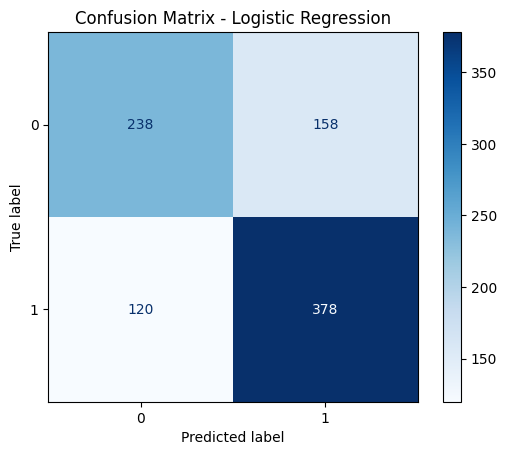

Brier Score: 0.20501402911311775


In [ ]:
# Create and train the model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train_lr = pd.concat([red_train.reset_index(drop=True),
                 blue_train.reset_index(drop=True),
                 fav_train.reset_index(drop=True),
                 dog_train.reset_index(drop=True)],
                axis=1)

X_test_lr = pd.concat([red_test.reset_index(drop=True),
                 blue_test.reset_index(drop=True),
                 fav_test.reset_index(drop=True),
                 dog_test.reset_index(drop=True)],
                axis=1)

class_weights = {0:1, 1: 1}
model = LogisticRegression(max_iter=5000,  class_weight=class_weights)
model.fit(X_train_lr, y_train)

# Predict
y_pred = model.predict(X_test_lr)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

probs = model.predict_proba(X_test_lr)[:, 1]   # probability of class 1
brier = brier_score_loss(y_test, probs)
print("Brier Score:", brier)

In [90]:

train_len = len(X_train)
y_test_pd = pd.DataFrame({
    'winner': y_test,
    'dec_close1_red': df_builder.iloc[train_len:]['dec_close1_red'],
    'dec_close2_red': df_builder.iloc[train_len:]['dec_close1_red'],
    'dec_close1_blue': df_builder.iloc[train_len:]['dec_close1_blue'],
    'dec_close2_blue': df_builder.iloc[train_len:]['dec_close2_blue']
})

df_results = pd.concat([X_test_lr.reset_index(drop=True), y_test_pd.reset_index(drop=True)], axis=1)
df_results['red_probs'] = probs
df_results['blue_probs'] = 1-probs
df_results['pred_winner'] = np.where(df_results['red_probs'] > df_results['blue_probs'],1,0)

calc_net_odds(df_results, 'close2')

calc_net_odds(df_results, 'close1')

Sum of decimal odds for favorite predictions (adjusted): 14.860273056299413
Sum of decimal odds for underdog predictions (adjusted): 13.743601479571167
Fav bets: 449 total, 322 correct, 127 incorrect, 71.71% correct
Dog bets: 80 total, 44 correct, 36 incorrect, 55.00% correct
Sum of decimal odds for favorite predictions (adjusted): 5.49614612317652
Sum of decimal odds for underdog predictions (adjusted): 11.644242385504247
Fav bets: 395 total, 286 correct, 109 incorrect, 72.41% correct
Dog bets: 85 total, 47 correct, 38 incorrect, 55.29% correct


In [78]:
for c in X_train_lr.columns:
    print(c)

open_red
close1_red
close2_red
juice_close1_red
juice_close2_red
juice_open_red
win_pct_red
ko_wins_red
sub_wins_red
fav_counts_red
dog_counts_red
line_movement_close1_red
line_movement_close2_red
proba_fair_open_red
ratio_td_red
max_elo_win_red
max_glicko_win_red
td_defense_pct_red
ratio_control_red
math_red
months_since_diff
num_fights_diff
wins_diff
losses_diff
decision_wins_diff
age_diff
reach_diff
sig_str_absorbed_total_diff
sig_str_absorbed_pm_diff
head_str_total_diff
kd_total_diff
td_attempted_pm_diff
td_attempted_total_diff
win_streak_diff
lose_streak_diff
total_bonus_diff
event_age
open_blue
close1_blue
close2_blue
juice_close1_blue
juice_close2_blue
juice_open_blue
win_pct_blue
ko_wins_blue
sub_wins_blue
fav_counts_blue
dog_counts_blue
line_movement_close1_blue
line_movement_close2_blue
proba_fair_open_blue
ratio_td_blue
max_elo_win_blue
max_glicko_win_blue
td_defense_pct_blue
ratio_control_blue
math_blue
months_since_diff
num_fights_diff
wins_diff
losses_diff
decision_wins_d

In [76]:
# Initialize CatBoostClassifier

scale_pos_weight = (len(y_train) - y_train.sum() ) / y_train.sum() 
print(scale_pos_weight)

#cat_features=cat_feats,

model = CatBoostClassifier(
    iterations=700,
    learning_rate=0.05,
    depth=5,
    task_type='GPU',
    devices='0',
    scale_pos_weight=scale_pos_weight,

    # GPU-compatible anti-overfitting settings
    bootstrap_type='Bernoulli',   # needed for subsample
    subsample=0.8,

    l2_leaf_reg=5,                 # L2 regularization
    random_strength=1.0,           # noise → prevents overfitting
    min_data_in_leaf=20,           # prevents deep memorization
    border_count=128,              # stable splitting

    # overfitting detector
    od_type='Iter',
    od_wait=50,

    eval_metric='F1',
    verbose=100
)

# Train the model
model.fit(X_train_lr, y_train)

# Make predictions
y_pred = model.predict(X_test_lr)
y_pred_train = model.predict(X_train_lr)

# Evaluate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

acc = accuracy_score(y_train, y_pred_train)
print(f"Train Accuracy: {acc:.4f}")

0.7379679144385026


CatBoostError: catboost/libs/data/features_layout.cpp:124: All feature names should be different, but 'months_since_diff' used more than once.

In [41]:
probs = model.predict_proba(X_test)[:, 1]   # probability of class 1
brier = brier_score_loss(y_test, probs)
print("Brier Score:", brier)

Brier Score: 0.2174471308583556


F1 Score: 0.6934156378600823
Confusion Matrix:
 [[259 137]
 [161 337]]


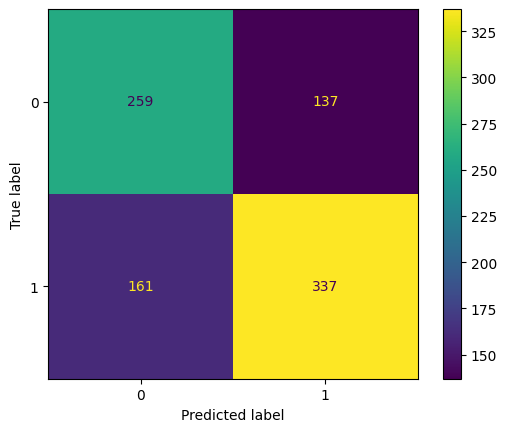

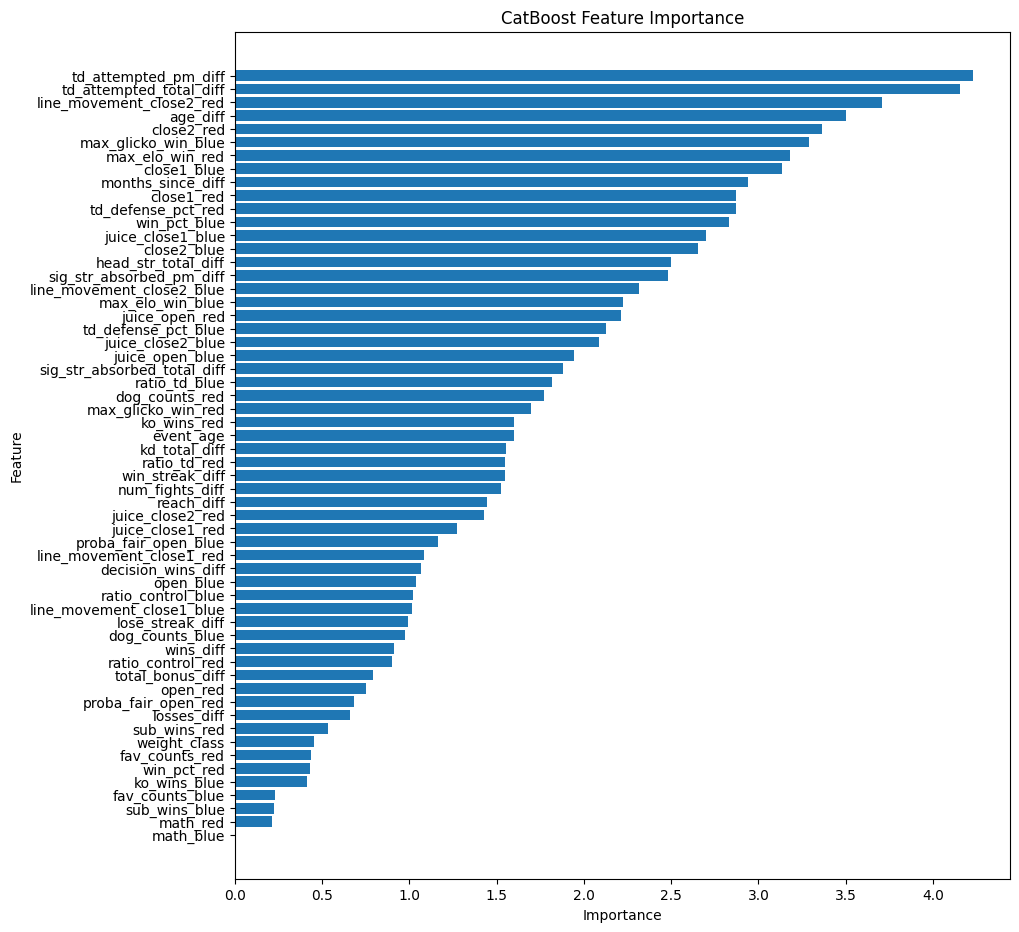

In [38]:
from catboost import Pool
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

# Predict
y_pred = model.predict(X_test)

# F1 score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# X_train is your features, model is trained CatBoostClassifier

# Feature importance as numbers
feature_importances = model.get_feature_importance(Pool(X_train, label=y_train, cat_features=cat_feats))
fi_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)


plt.figure(figsize=(10,11))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('CatBoost Feature Importance')
plt.gca().invert_yaxis()  # largest on top
plt.show()

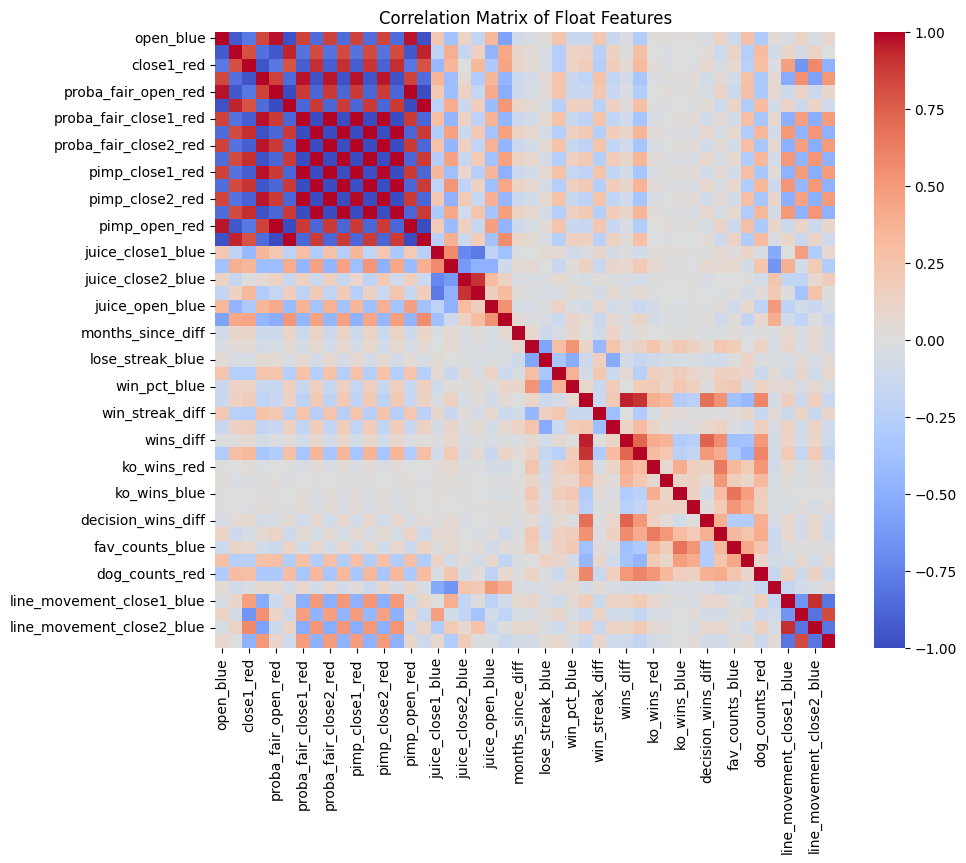

In [56]:
import seaborn as sns 
# Select numerical columns that are not integers
# Select numerical columns that are not integers
num_cols = X_train.select_dtypes(include=['float64', 'float32']).columns

# Compute correlation matrix
corr_matrix = X_train[num_cols].corr()

# Display as a heatmap without numbers
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Float Features")
plt.show()

In [87]:
def split_red_blue_features(df: pd.DataFrame):

    red_cols = [c for c in df.columns if "red" in c]
    blue_cols = [c for c in df.columns if "blue" in c]
    diff_cols = [c for c in df.columns if "diff" in c]

    # Construct red dataframe
    red_df = df[red_cols + diff_cols].copy()
    if 'event_age' in df.columns:
        red_df['event_age'] = df['event_age']

    # Construct blue dataframe
    blue_df = df[blue_cols].copy()
    for c in diff_cols:
        blue_df[c] = -df[c]  # negate diffs for blue
    if 'event_age' in df.columns:
        blue_df['event_age'] = df['event_age']
    # Update blue_cols to include diffs as well
    blue_cols = blue_cols + diff_cols

    return red_df, blue_df, red_cols + diff_cols, blue_cols

def split_fav_dog(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Splits dataset into favorite (fav) and underdog (dog) based on open odds.
    Standardizes column names to fav_* and dog_*.
    Adjusts 'diff' columns so that they are always (fav - dog).
    
    Args:
        df (pd.DataFrame): Input dataframe with 'open_red' and 'open_blue'.
    
    Returns:
        fav_df (pd.DataFrame): Rows corresponding to the favorite (fav_* + diff_*).
        dog_df (pd.DataFrame): Rows corresponding to the underdog (dog_* + diff_*).
    """
    fav_rows = []
    dog_rows = []

    df = df.copy()
    df = df.drop(columns=['fav_counts_red', 'dog_counts_red', 'fav_counts_blue', 'dog_counts_blue'])

    for _, row in df.iterrows():
        # --- case: red is favorite ---
        if row["open_red"] < row["open_blue"]:
            fav_row = {col.replace("red", "fav"): row[col] for col in row.index if "red" in col}
            dog_row = {col.replace("blue", "dog"): row[col] for col in row.index if "blue" in col}
            diff_row = {col.replace("diff", "diff"): row[col] for col in row.index if "diff" in col}

        # --- case: blue is favorite ---
        elif row["open_blue"] < row["open_red"]:
            fav_row = {col.replace("blue", "fav"): row[col] for col in row.index if "blue" in col}
            dog_row = {col.replace("red", "dog"): row[col] for col in row.index if "red" in col}
            diff_row = {col.replace("diff", "diff"): -row[col] for col in row.index if "diff" in col}

        # --- case: tie → red as favorite ---
        else:
            fav_row = {col.replace("red", "fav"): row[col] for col in row.index if "red" in col}
            dog_row = {col.replace("blue", "dog"): row[col] for col in row.index if "blue" in col}
            diff_row = {col.replace("diff", "diff"): row[col] for col in row.index if "diff" in col}
        
        fav_row['event_age'] = row['event_age']
        dog_row['event_age'] = row['event_age']

        fav_row.update(diff_row)
        dog_row.update(diff_row)

        fav_rows.append(fav_row)
        dog_rows.append(dog_row)
    
    fav_df = pd.DataFrame(fav_rows)
    dog_df = pd.DataFrame(dog_rows)

    
    y_fav_dog = []
    for _, row in df.iterrows():
        # Determine who is favorite
        if row['open_red'] <= row['open_blue']:  # red is fav or tie → red fav
            fav_won = 1 if row['winner'] == 1 else 0
        else:  # blue is fav
            fav_won = 1 if row['winner'] == 0 else 0
        
        y_fav_dog.append(fav_won)
    print(df['event_age'].isna().sum())
    return fav_df, dog_df, np.array(y_fav_dog)

In [94]:
red_train, blue_train, red_cols, blue_cols = split_red_blue_features(X_train)
red_test, blue_test, _, _ = split_red_blue_features(X_test)

fav_train, dog_train, y_favdog_train = split_fav_dog(pd.concat([X_train, y_train],axis=1, ignore_index=False))
fav_test, dog_test, y_favdog_test = split_fav_dog(pd.concat([X_test, y_test],axis=1, ignore_index=False))

print(red_test.shape, blue_test.shape, red_train.shape, blue_train.shape)
print(fav_test.shape, dog_test.shape, fav_train.shape, dog_train.shape)

0
0
(429, 56) (429, 56) (1712, 56) (1712, 56)
(429, 54) (429, 54) (1712, 54) (1712, 54)


In [95]:
pd.set_option('display.max_rows', None)

fav_test.isna().sum()

dec_fair_open_fav        0
proba_fair_open_fav      0
dec_close1_fav           0
dec_close2_fav           0
proba_fair_close1_fav    0
proba_fair_close2_fav    0
pimp_close1_fav          0
pimp_close2_fav          0
juice_close1_fav         0
juice_close2_fav         0
dec_fair_close1_fav      0
dec_fair_close2_fav      0
months_since_fav         0
win_streak_fav           0
lose_streak_fav          0
win_pct_fav              0
num_fights_fav           0
num_wins_fav             0
num_losses_fav           0
decision_wins_fav        0
ko_wins_fav              0
sub_wins_fav             0
open_fav                 0
proba_open_fav           0
reach_fav                0
age_fav                  0
height_fav               0
total_bonus_fav          0
reverse_pm_fav           0
td_defended_total_fav    0
td_landed_total_fav      0
kd_total_fav             0
math_fav                 0
fav_ud_to_fav_close1     0
fav_ud_to_fav_close2     0
fav_stayed_fav_close1    0
fav_stayed_fav_close2    0
f

In [82]:
def build_full_combination_pyramid(input_dim_red, input_dim_blue, input_dim_fav, input_dim_dog, dropout_rate=0.2):
    # --- Individual subnetworks ---
    def shallow_subnet(input_dim, name_prefix):
        inp = Input(shape=(input_dim,), name=f"{name_prefix}_input")
        x = layers.Dense(32)(inp)
        x = layers.BatchNormalization(momentum=0.96)(x)
        # x = layers.Activation("relu")(x)
        x = layers.ELU(alpha=.3)(x)
        x = layers.Dropout(dropout_rate)(x)
        return inp, x

    # Create subnetworks
    red_input, red_feat = shallow_subnet(input_dim_red, "red")
    blue_input, blue_feat = shallow_subnet(input_dim_blue, "blue")
    fav_input, fav_feat = shallow_subnet(input_dim_fav, "fav")
    dog_input, dog_feat = shallow_subnet(input_dim_dog, "dog")

    features = {
        "red": red_feat,
        "blue": blue_feat,
        "fav": fav_feat,
        "dog": dog_feat
    }

    # --- All pairwise concatenations ---
    concat_features = {}
    for a, b in combinations(features.keys(), 2):
        concat = layers.Concatenate(name=f"{a}_{b}_concat")([features[a], features[b]])

        # concat = layers.Dense(128)(concat)
        # concat = layers.BatchNormalization(momentum=0.96)(concat)
        # # concat = layers.ELU(alpha=0.3)(concat)
        # concat = layers.Activation("relu")(concat)
        # concat = layers.Dropout(dropout_rate)(concat)

        concat = layers.Dense(32)(concat)
        concat = layers.BatchNormalization(momentum=0.95)(concat)
        concat = layers.ELU(alpha=.32)(concat)
        concat = layers.Dropout(dropout_rate)(concat)

        concat_features[f"{a}_{b}"] = concat

    # --- Final concatenation of all pairwise combinations ---
    all_concat = layers.Concatenate(name="final_concat")(
        list(concat_features.values())
    )

    # all_concat = layers.Dense(128)(all_concat)
    # all_concat = layers.BatchNormalization(momentum=0.9)(all_concat)
    # all_concat = layers.ELU(alpha=0.3)(all_concat)
    # all_concat = layers.Dropout(dropout_rate)(all_concat)

    all_concat = layers.Dense(64)(all_concat)
    all_concat = layers.BatchNormalization(momentum=0.92)(all_concat)
    # all_concat = layers.ELU(alpha=0.3)(all_concat)
    all_concat = layers.Activation("relu")(all_concat)
    all_concat = layers.Dropout(dropout_rate)(all_concat)

    all_concat = layers.Dense(32)(all_concat)
    all_concat = layers.BatchNormalization(momentum=0.92)(all_concat)
    all_concat = layers.ELU(alpha=0.3)(all_concat)
    # all_concat = layers.Activation("relu")(all_concat)
    all_concat = layers.Dropout(dropout_rate)(all_concat)

    # all_concat = layers.Dense(16)(all_concat)
    # all_concat = layers.BatchNormalization(momentum=0.92)(all_concat)
    # # all_concat = layers.ELU(alpha=0.3)(all_concat)
    # all_concat = layers.Activation("relu")(all_concat)
    # all_concat = layers.Dropout(dropout_rate)(all_concat)


    output = layers.Dense(1, activation="sigmoid", name="final_output")(all_concat)

    # Model
    model = Model(
        inputs=[red_input, blue_input, fav_input, dog_input],
        outputs=[output] 
    )
    
    return model

In [97]:
model = build_full_combination_pyramid(
    input_dim_red=red_train.shape[1],
    input_dim_blue=blue_train.shape[1],
    input_dim_fav=fav_train.shape[1],
    input_dim_dog=dog_train.shape[1]
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.7,
    patience=10,
    min_lr=1e-6
)

def brier_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
    return tf.reduce_mean(tf.square(y_pred - y_true))

model.compile(
    optimizer=tf.keras.optimizers.Adam(.001),
    loss=brier_loss,
    metrics=["accuracy"]
)
# full_train_acc_callback = FullTrainAccuracyCallback([fav_train, dog_train], y_favdog_train)

history = model.fit(
    [red_train, blue_train, fav_train, dog_train], y_train,
    validation_data=([red_test, blue_test, fav_test, dog_test], y_test),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[reduce_lr]
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5498 - loss: 0.2767 - val_accuracy: 0.5851 - val_loss: 0.2420 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6300 - loss: 0.2377 - val_accuracy: 0.6131 - val_loss: 0.2330 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6370 - loss: 0.2247 - val_accuracy: 0.6247 - val_loss: 0.2329 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6395 - loss: 0.2200 - val_accuracy: 0.6131 - val_loss: 0.2323 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6722 - loss: 0.2160 - val_accuracy: 0.6154 - val_loss: 0.2306 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6465 - loss: 0.2167 - val_accuracy: 0.6247 - val_loss: 0.2263 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6595 - loss: 0.2107 - val_acc